In [83]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_mistralai import ChatMistralAI
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver



In [84]:
llm = ChatMistralAI(
    model="mistral-large-latest",
    temperature=0.7
)

In [85]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]


In [86]:
def chat_node(state:ChatState)->ChatState:
   messages = state["messages"] 
   response = llm.invoke(messages)
   return {"messages":[response]}


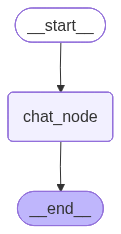

In [97]:

checkpointer = MemorySaver()
#lets create graph
graph = StateGraph(ChatState)

# add nodes
graph.add_node("chat_node",chat_node)

#add edges
graph.add_edge(START,"chat_node")

graph.add_edge("chat_node",END)


workflow = graph.compile(checkpointer=checkpointer)
workflow




In [93]:
thread_id = "1"
while True:
    user_message = input('Type here: ')

    print('User:', user_message)

    if user_message.strip().lower() in ['exit', 'quit', 'bye']:
        break
    config = {"configurable":{"thread_id":thread_id}}
    response = workflow.invoke({'messages': [HumanMessage(content=user_message)]},config=config)

    print('AI:', response['messages'][-1].content)


User: what is 2+3
AI: The answer to **2 + 3** is **5**! 😊

Need help with anything else? Math, tech, or just a fun fact? Let me know! 🚀
User: bye


In [96]:
workflow.get_state(config)

StateSnapshot(values={'messages': [HumanMessage(content='my name is ali', additional_kwargs={}, response_metadata={}, id='7e346634-276e-4418-aaa6-59ad6d20a4bb'), AIMessage(content="Nice to meet you, Ali! 😊 How can I help you today? Whether you have questions, need advice, or just want to chat, I'm here for it. What's on your mind?", additional_kwargs={}, response_metadata={'token_usage': {'prompt_tokens': 7, 'total_tokens': 51, 'completion_tokens': 44, 'prompt_tokens_details': {'cached_tokens': 0}}, 'model_name': 'mistral-large-latest', 'model': 'mistral-large-latest', 'finish_reason': 'stop', 'model_provider': 'mistralai'}, id='lc_run--019f13f8-ad43-7132-8f9f-c06e622018b0-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 7, 'output_tokens': 44, 'total_tokens': 51}), HumanMessage(content='who is the ceo of microsoft', additional_kwargs={}, response_metadata={}, id='12fa435b-24bc-4a81-8c0a-165d1524050b'), AIMessage(content='As of **June 2024**, the **CEO of Micro

In [95]:
list(workflow.get_state_history(config))

[StateSnapshot(values={'messages': [HumanMessage(content='my name is ali', additional_kwargs={}, response_metadata={}, id='7e346634-276e-4418-aaa6-59ad6d20a4bb'), AIMessage(content="Nice to meet you, Ali! 😊 How can I help you today? Whether you have questions, need advice, or just want to chat, I'm here for it. What's on your mind?", additional_kwargs={}, response_metadata={'token_usage': {'prompt_tokens': 7, 'total_tokens': 51, 'completion_tokens': 44, 'prompt_tokens_details': {'cached_tokens': 0}}, 'model_name': 'mistral-large-latest', 'model': 'mistral-large-latest', 'finish_reason': 'stop', 'model_provider': 'mistralai'}, id='lc_run--019f13f8-ad43-7132-8f9f-c06e622018b0-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 7, 'output_tokens': 44, 'total_tokens': 51}), HumanMessage(content='who is the ceo of microsoft', additional_kwargs={}, response_metadata={}, id='12fa435b-24bc-4a81-8c0a-165d1524050b'), AIMessage(content='As of **June 2024**, the **CEO of Micr